In [23]:
import re
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── find all .out files under Assets/Agents ──────────────────────────────────
agents_dir = "Assets/Agents"
out_files = sorted(glob.glob(f"{agents_dir}/**/*.out", recursive=True))
print("Found runs:")
for i, f in enumerate(out_files):
    print(f"  [{i}] {f}")

Found runs:
  [0] Assets/Agents\car_run_17052127\train_17052127.out
  [1] Assets/Agents\car_run_17076498_30m_256\train_17076498.out
  [2] Assets/Agents\car_run_17099733_com\train_17099733.out


In [24]:
def _get(line, pattern, cast=float, default=0):
    """Extract a field from a log line; strips trailing period left by mlagents separator."""
    m = re.search(pattern, line)
    return cast(m.group(1).rstrip('.')) if m else cast(default)

def parse_out_file(filepath):
    """Parse an mlagents .out log into a list of dicts, one per summary line."""
    records = []
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            if 'Mean Reward:' not in line:
                continue
            records.append({
                'step':       _get(line, r'Step: (\d+)',                     int),
                'episodes':   _get(line, r'Episodes: (\d+)',                 int),
                'mean_r':     _get(line, r'Mean Reward: ([\-\d.]+)',         float),
                'std_r':      _get(line, r'Std of Reward: ([\d.]+)',         float),
                'mean_len':   _get(line, r'Mean Episode Length: ([\d.]+)',   float),
                'std_len':    _get(line, r'Std of Episode Length: ([\d.]+)', float),
                'goals':      _get(line, r'Goals: (\d+)',                    int),
                'terminated': _get(line, r'Terminated: (\d+)',               int),
                'maxstep':    _get(line, r'MaxStep: (\d+)',                  int),
            })
    return records

# ── pick which run to plot (change index or hardcode a path) ─────────────────
RUN_INDEX = 2
filepath  = out_files[RUN_INDEX]
records   = parse_out_file(filepath)

print(f"Run : {os.path.basename(filepath)}")
print(f"Rows: {len(records)}")
print(f"Steps: {records[0]['step']:,} → {records[-1]['step']:,}")

Run : train_17099733.out
Rows: 1200
Steps: 25,000 → 30,000,000


In [25]:
# ── convert to numpy arrays ──────────────────────────────────────────────────
steps    = np.array([r['step']       for r in records])
episodes = np.array([r['episodes']   for r in records])
mean_r   = np.array([r['mean_r']     for r in records])
std_r    = np.array([r['std_r']      for r in records])
mean_len = np.array([r['mean_len']   for r in records])
std_len  = np.array([r['std_len']    for r in records])
goals    = np.array([r['goals']      for r in records])
term     = np.array([r['terminated'] for r in records])
maxstep  = np.array([r['maxstep']    for r in records])

# episodes that ended but weren't logged in any category
other    = np.maximum(0, episodes - goals - term - maxstep)

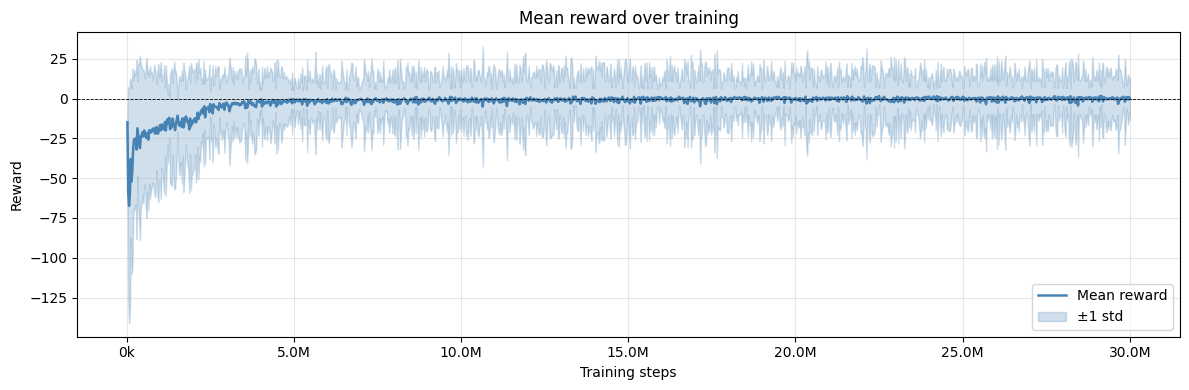

In [26]:
# ── Plot 1 : Mean Reward ± Std ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(steps, mean_r, color='steelblue', linewidth=1.8, label='Mean reward')
ax.fill_between(steps,
                mean_r - std_r,
                mean_r + std_r,
                color='steelblue', alpha=0.25, label='±1 std')
ax.axhline(0, color='black', linewidth=0.6, linestyle='--')

ax.set_xlabel('Training steps')
ax.set_ylabel('Reward')
ax.set_title('Mean reward over training')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}k'))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_reward.png', dpi=150)
plt.show()

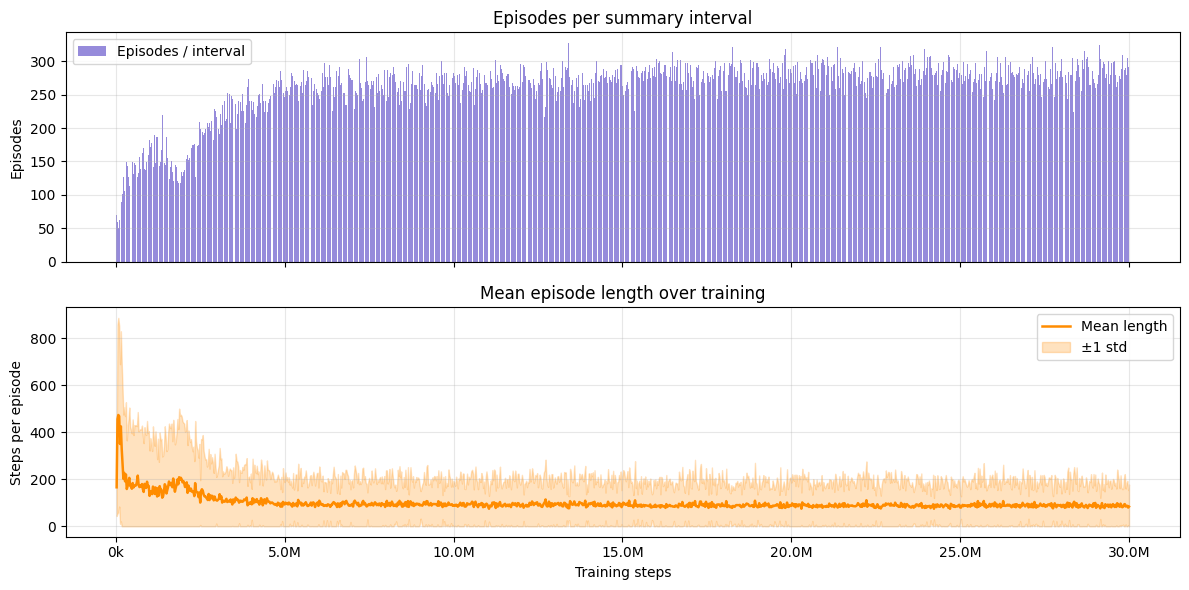

In [27]:
# ── Plot 2 : Episode count and mean episode length ───────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# top: episodes per summary interval
ax1.bar(steps, episodes, width=(steps[1]-steps[0])*0.8 if len(steps)>1 else 5000,
        color='slateblue', alpha=0.7, label='Episodes / interval')
ax1.set_ylabel('Episodes')
ax1.set_title('Episodes per summary interval')
ax1.legend()
ax1.grid(True, alpha=0.3)

# bottom: mean episode length ± std
ax2.plot(steps, mean_len, color='darkorange', linewidth=1.8, label='Mean length')
ax2.fill_between(steps,
                 np.maximum(0, mean_len - std_len),
                 mean_len + std_len,
                 color='darkorange', alpha=0.25, label='±1 std')
ax2.set_xlabel('Training steps')
ax2.set_ylabel('Steps per episode')
ax2.set_title('Mean episode length over training')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}k'))
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plot_episodes.png', dpi=150)
plt.show()

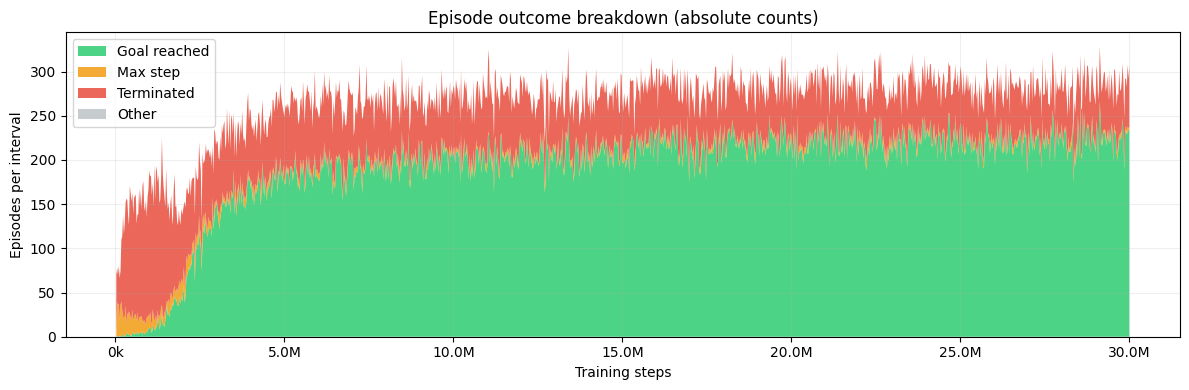

In [28]:
# ── Plot 3 : Episode outcomes ────────────────────────────────────────────────
#
# Three approaches — uncomment the one you prefer:
#
#  A) 100% stacked area  → shows proportion of each outcome over time
#                          best for seeing whether goal-rate is rising
#
#  B) Absolute stacked area → shows raw counts, height = total episodes
#                              good for seeing training throughput changes
#
#  C) Success-rate line  → single line: goals / episodes (0–1)
#                          cleanest way to track improvement

STYLE = 'B'   # change to 'B' or 'C'

COLORS = {
    'Goal':       '#2ecc71',   # green
    'MaxStep':    '#f39c12',   # orange
    'Terminated': '#e74c3c',   # red
    'Other':      '#bdc3c7',   # grey
}

fig, ax = plt.subplots(figsize=(12, 4))

if STYLE == 'A':
    total   = goals + term + maxstep + other
    total   = np.where(total == 0, 1, total)   # avoid /0
    g_pct   = goals   / total * 100
    ms_pct  = maxstep / total * 100
    t_pct   = term    / total * 100
    o_pct   = other   / total * 100

    ax.stackplot(steps,
                 g_pct, ms_pct, t_pct, o_pct,
                 labels=['Goal reached', 'Max step', 'Terminated', 'Other'],
                 colors=[COLORS['Goal'], COLORS['MaxStep'],
                         COLORS['Terminated'], COLORS['Other']],
                 alpha=0.85)
    ax.set_ylabel('% of episodes')
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_title('Episode outcome breakdown (proportions)')

elif STYLE == 'B':
    ax.stackplot(steps,
                 goals, maxstep, term, other,
                 labels=['Goal reached', 'Max step', 'Terminated', 'Other'],
                 colors=[COLORS['Goal'], COLORS['MaxStep'],
                         COLORS['Terminated'], COLORS['Other']],
                 alpha=0.85)
    ax.set_ylabel('Episodes per interval')
    ax.set_title('Episode outcome breakdown (absolute counts)')

elif STYLE == 'C':
    total        = np.where(episodes == 0, 1, episodes)
    success_rate = goals / total
    # smooth with a rolling window
    window       = max(1, len(success_rate) // 10)
    smoothed     = np.convolve(success_rate, np.ones(window)/window, mode='same')

    ax.plot(steps, success_rate, color=COLORS['Goal'], alpha=0.35, linewidth=1)
    ax.plot(steps, smoothed,     color=COLORS['Goal'], linewidth=2, label='Goal rate (smoothed)')
    ax.set_ylabel('Goals / total episodes')
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title('Goal success rate over training')

ax.set_xlabel('Training steps')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}k'))
ax.legend(loc='upper left')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('plot_outcomes.png', dpi=150)
plt.show()

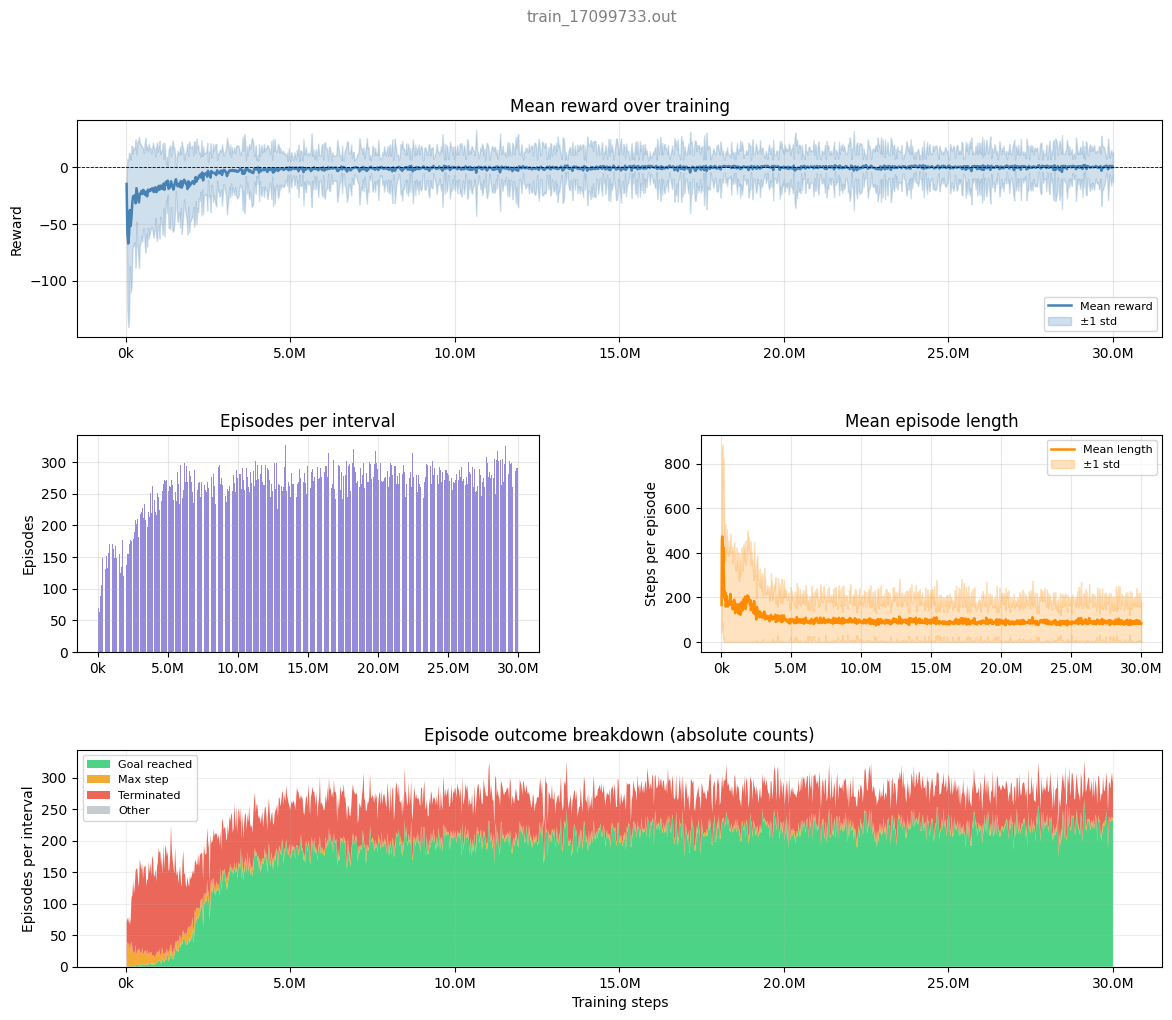

Saved → plot_combined.png


In [29]:
# ── Combined figure : all three plots in one image ───────────────────────────
fig = plt.figure(figsize=(14, 11))
gs  = fig.add_gridspec(3, 2, hspace=0.45, wspace=0.35)

ax_reward  = fig.add_subplot(gs[0, :])   # row 0, full width
ax_epcount = fig.add_subplot(gs[1, 0])   # row 1, left
ax_eplen   = fig.add_subplot(gs[1, 1])   # row 1, right
ax_outcome = fig.add_subplot(gs[2, :])   # row 2, full width

run_name = os.path.basename(filepath)
fig.suptitle(run_name, fontsize=11, color='grey')

step_fmt = mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}k'
)

# ── 1. Mean reward ± std ─────────────────────────────────────────────────────
ax_reward.plot(steps, mean_r, color='steelblue', linewidth=1.8, label='Mean reward')
ax_reward.fill_between(steps, mean_r - std_r, mean_r + std_r,
                        color='steelblue', alpha=0.25, label='±1 std')
ax_reward.axhline(0, color='black', linewidth=0.6, linestyle='--')
ax_reward.set_ylabel('Reward')
ax_reward.set_title('Mean reward over training')
ax_reward.xaxis.set_major_formatter(step_fmt)
ax_reward.legend(fontsize=8)
ax_reward.grid(True, alpha=0.3)

# ── 2a. Episodes per interval ────────────────────────────────────────────────
bar_w = (steps[1] - steps[0]) * 0.8 if len(steps) > 1 else 5000
ax_epcount.bar(steps, episodes, width=bar_w, color='slateblue', alpha=0.7)
ax_epcount.set_ylabel('Episodes')
ax_epcount.set_title('Episodes per interval')
ax_epcount.xaxis.set_major_formatter(step_fmt)
ax_epcount.grid(True, alpha=0.3)

# ── 2b. Mean episode length ± std ────────────────────────────────────────────
ax_eplen.plot(steps, mean_len, color='darkorange', linewidth=1.8, label='Mean length')
ax_eplen.fill_between(steps,
                      np.maximum(0, mean_len - std_len), mean_len + std_len,
                      color='darkorange', alpha=0.25, label='±1 std')
ax_eplen.set_ylabel('Steps per episode')
ax_eplen.set_title('Mean episode length')
ax_eplen.xaxis.set_major_formatter(step_fmt)
ax_eplen.legend(fontsize=8)
ax_eplen.grid(True, alpha=0.3)

# ── 3. Outcome breakdown (absolute stacked area — style B) ───────────────────
COLORS = {'Goal': '#2ecc71', 'MaxStep': '#f39c12', 'Terminated': '#e74c3c', 'Other': '#bdc3c7'}
ax_outcome.stackplot(
    steps,
    goals, maxstep, term, other,
    labels=['Goal reached', 'Max step', 'Terminated', 'Other'],
    colors=[COLORS['Goal'], COLORS['MaxStep'], COLORS['Terminated'], COLORS['Other']],
    alpha=0.85,
)
ax_outcome.set_ylabel('Episodes per interval')
ax_outcome.set_title('Episode outcome breakdown (absolute counts)')
ax_outcome.xaxis.set_major_formatter(step_fmt)
ax_outcome.set_xlabel('Training steps')
ax_outcome.legend(loc='upper left', fontsize=8)
ax_outcome.grid(True, alpha=0.2)

plt.savefig('plot_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → plot_combined.png")